# Part 2: Commit Activity

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("dbritto3_project_summary.csv", sep=";")
df.columns = ['project', 'commit', 'author', 'time', 'message']
df['Month'] = pd.to_datetime(df['time'], unit='s', utc=True).dt.strftime('%Y-%m')
df.head()

,project,commit,author,time,message,Month
0,apache_ctakes,000271f3940e5c277416b7dd2ede108da8aac4a7,Sean Finan <seanfinan@apache.org>,1484780774,"Write XMIs in tree, write using addLast\n\ngit...",2017-01
1,apache_ctakes,0016a61c5ab40ab4ba90b2e38be6ffab17d3bae9,Sean Patrick Murphy <spmurphy50@apache.org>,1318604266,Fixes for version 1.2.0.\n\ngit-svn-id: https:...,2011-10
2,apache_ctakes,0025b3c78fbf04c4f385706530a98443572d54f7,Tim Miller <tmill@apache.org>,1398456388,CTAKES-16: Fix to use UIMAFit select instead o...,2014-04
3,apache_ctakes,003084326b094e482e77f2611043542d9ddc20e4,Pei Chen <chenpei@apache.org>,1481857480,CTAKES-411 Fix JUnit tests for mvn package\n\n...,2016-12
4,apache_ctakes,0034fa0d89d089d03a14a0a896b3cdab13d2d3c0,chenpei <chenpei@13f79535-47bb-0310-9956-ffa45...,1383599215,CTAKES-253 - Didn't need an additional .length...,2013-11


## Monthly Counts and Plots

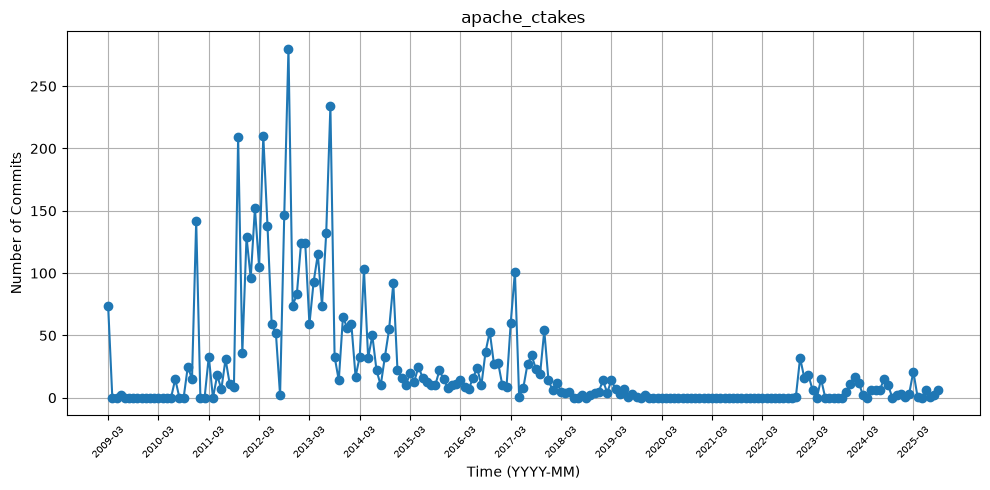

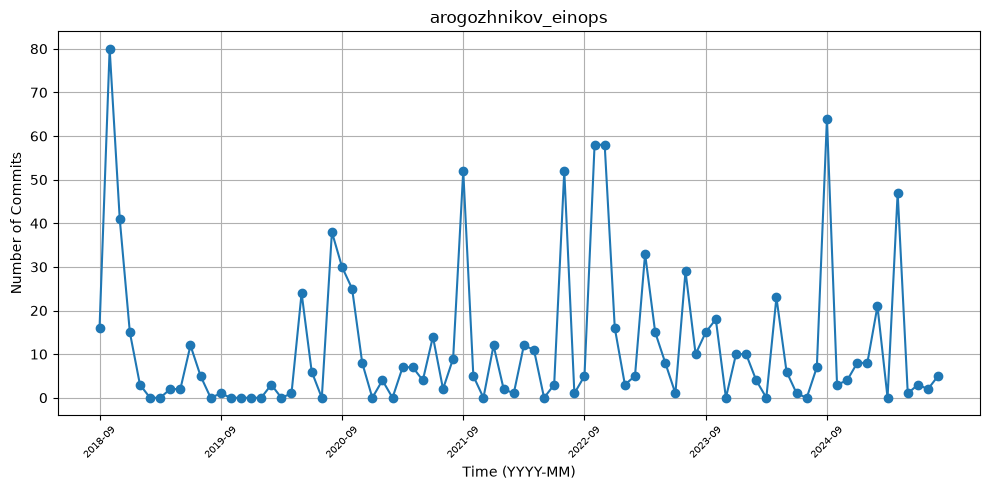

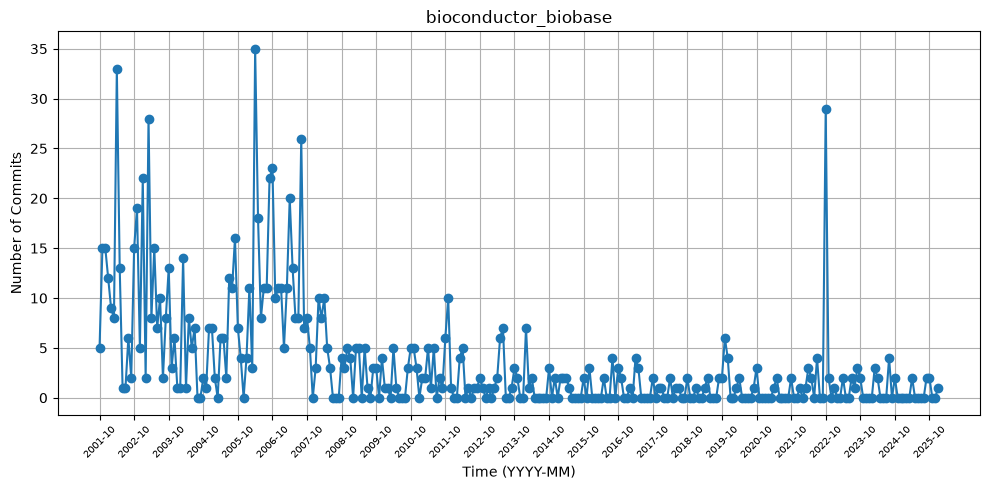

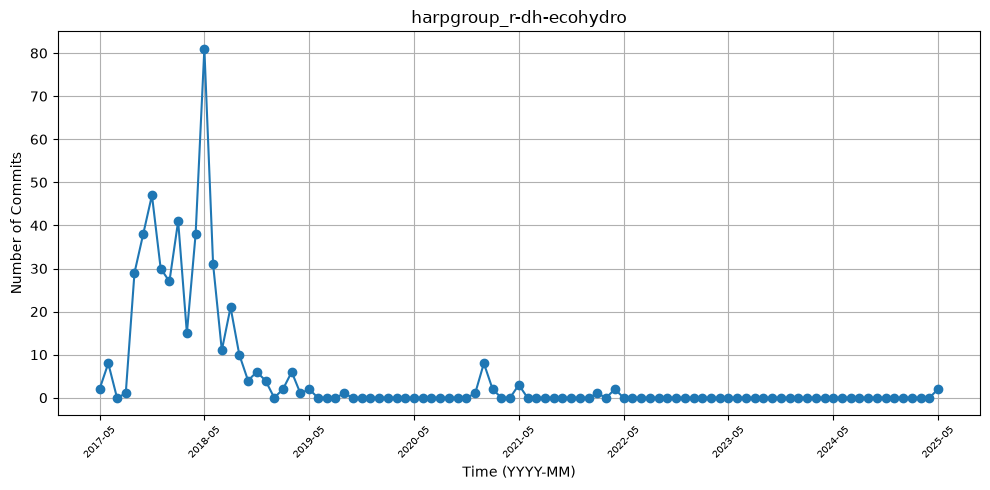

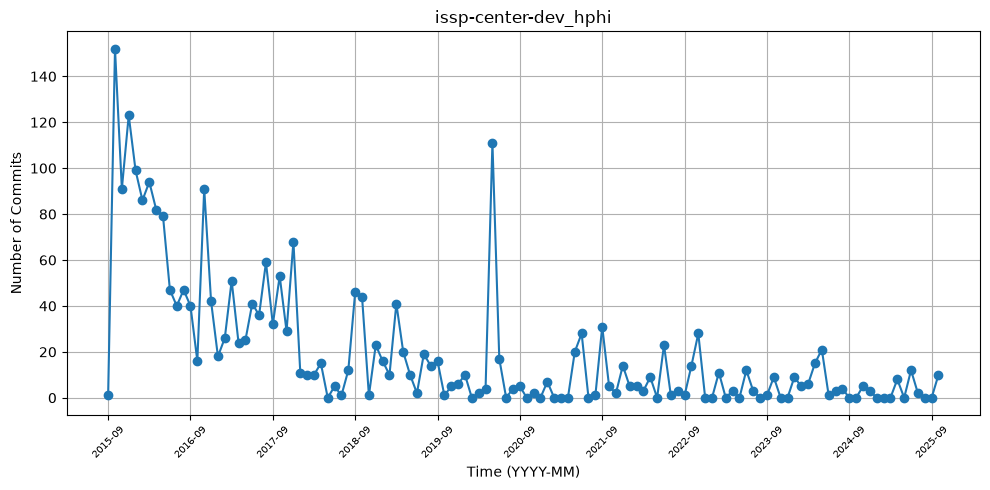

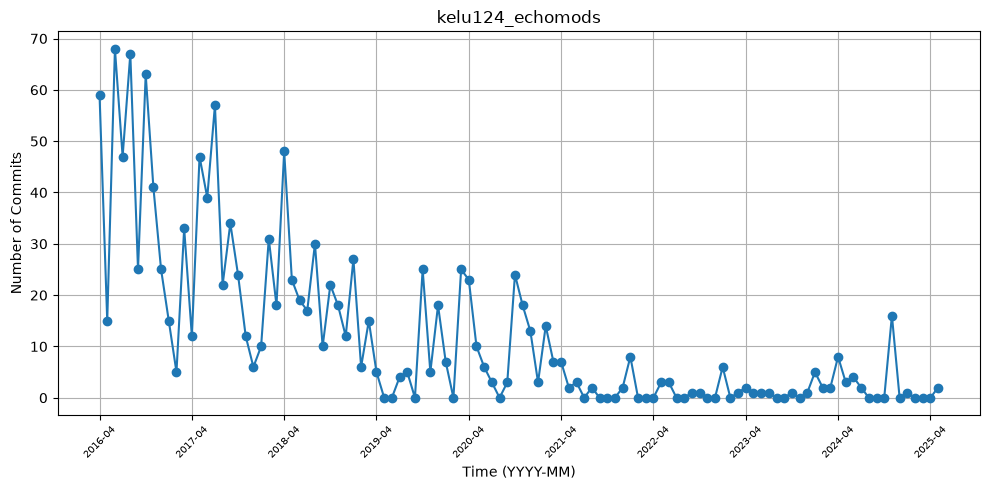

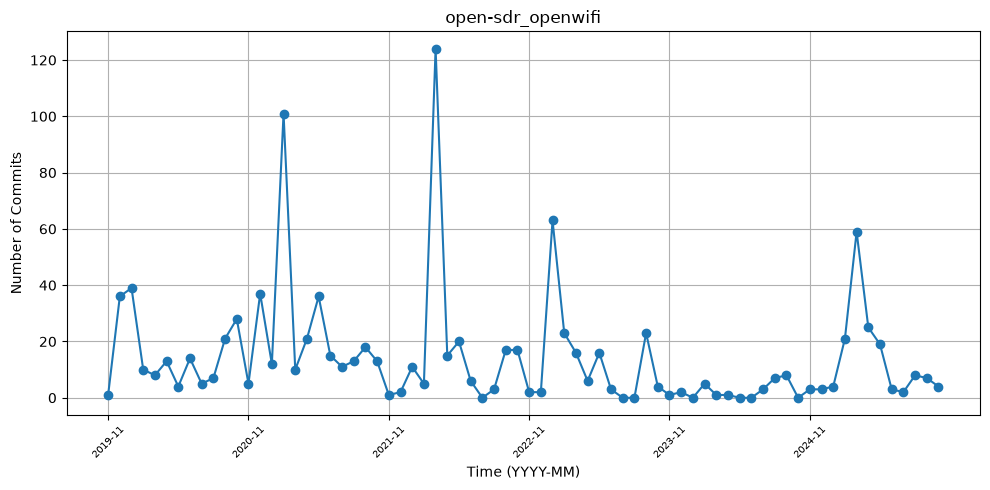

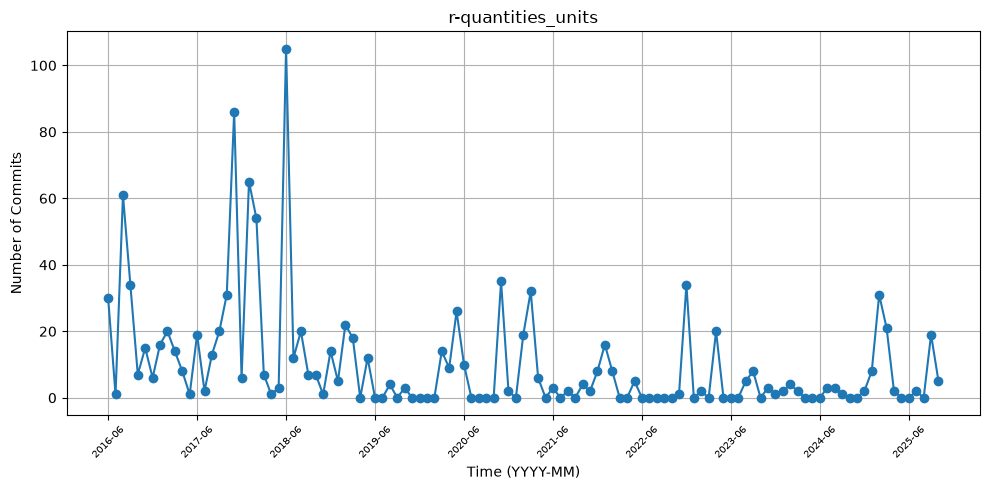

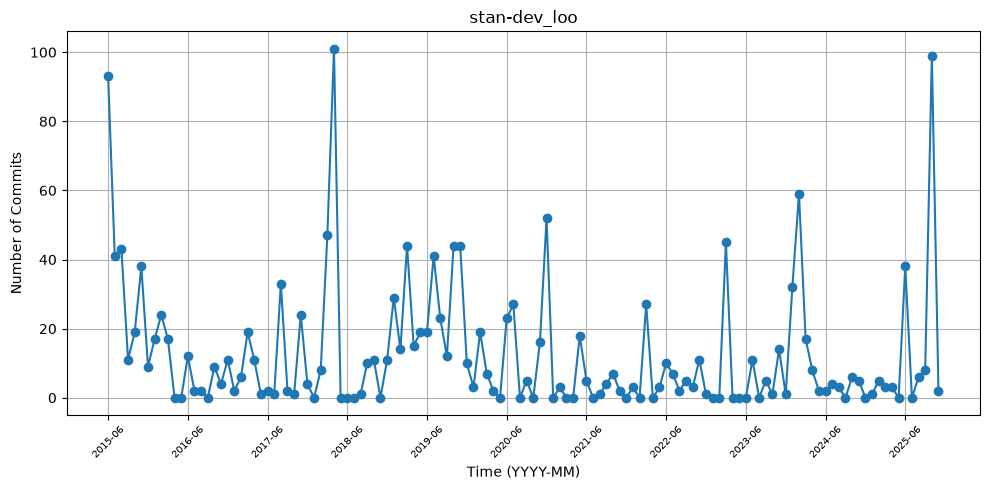

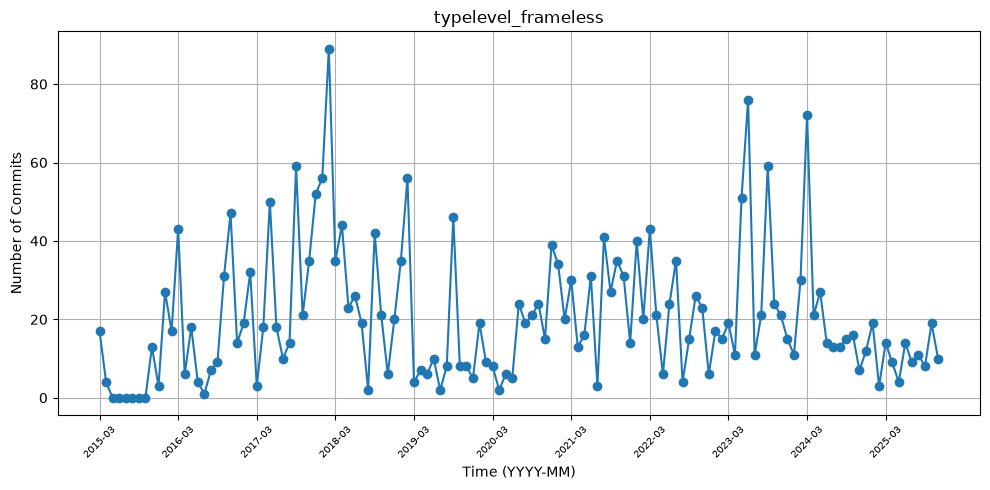

In [3]:
for prj in sorted(df['project'].unique()):
    df1 = df[df['project'] == prj]
    df2 = df1.groupby('Month').size().reset_index(name='Commits')
    monthly_counts = df2
    monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
    full_date_range = pd.DataFrame({'time': pd.date_range(
        start=monthly_counts['time'].min(),
        end=monthly_counts['time'].max(), freq='MS')})
    monthly_counts = pd.merge(full_date_range, monthly_counts, on='time', how='left').fillna(0)
    monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')
    monthly_counts['Commits'] = monthly_counts['Commits'].astype(int)

    monthly_counts[['Month', 'Commits']].to_csv(
        'dbritto3_commits_timeseries_' + prj + '.csv',
        sep=';', index=False, header=['Month', '#Commits'])

    plt.figure(figsize=(10, 5))
    plt.plot(monthly_counts['Month'], monthly_counts['Commits'], marker='o', linestyle='-')
    plt.xlabel('Time (YYYY-MM)')
    plt.ylabel('Number of Commits')
    plt.title(prj)
    plt.grid(True)
    # Label one month per year to keep the dates readable.
    plt.xticks(monthly_counts['Month'][::12], rotation=45, fontsize=7)
    plt.tight_layout()
    plt.savefig('dbritto3_timeseries_' + prj + '.png', dpi=300)
    plt.show()
    plt.close()

## Identify the Longest Inactivity Gap

Find the longest zero-commit gap and count gaps lasting at least three months.

In [4]:
gap_rows = []

for prj in sorted(df['project'].unique()):
    monthly_counts = pd.read_csv('dbritto3_commits_timeseries_' + prj + '.csv', sep=';')
    monthly_counts.columns = ['Month', 'Commits']
    gap_length = 0
    longest_start = ''
    longest_end = ''
    longest_length = 0
    number_of_gaps = 0

    for i in range(len(monthly_counts)):
        commits = monthly_counts.loc[i, 'Commits']
        month = monthly_counts.loc[i, 'Month']

        if commits == 0:
            if gap_length == 0:
                gap_start = month
            gap_length += 1
        else:
            #counts gaps that lasted at least three months
            if gap_length >= 3:
                number_of_gaps += 1

            #keep the longest gap found so far
            if gap_length > longest_length:
                longest_start = gap_start
                longest_end = monthly_counts.loc[i - 1, 'Month']
                longest_length = gap_length

            gap_length = 0

    commits_after = 0
    if longest_length > 0:
        for i in range(len(monthly_counts)):
            if monthly_counts.loc[i, 'Month'] > longest_end:
                commits_after += monthly_counts.loc[i, 'Commits']

    gap_rows.append({
        'Project': prj,
        'LongestGapStart': longest_start,
        'LongestGapEnd': longest_end,
        'LongestGapLength': longest_length,
        'NumCommitsAfterLastGap': commits_after,
        'NumberOfGapsInTimeline': number_of_gaps
    })

gap_stats = pd.DataFrame(gap_rows)
gap_stats

,Project,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline
0,apache_ctakes,2019-12,2022-10,35,224,3
1,arogozhnikov_einops,2019-10,2020-01,4,834,1
2,bioconductor_biobase,2014-05,2014-09,5,147,14
3,harpgroup_r-dh-ecohydro,2022-05,2025-04,36,2,4
4,issp-center-dev_hphi,2021-02,2021-04,3,336,2
5,kelu124_echomods,2021-09,2021-11,3,77,4
6,open-sdr_openwifi,2023-07,2023-08,2,213,0
7,r-quantities_units,2022-06,2022-10,5,179,5
8,stan-dev_loo,2018-05,2018-07,3,993,2
9,typelevel_frameless,2015-05,2015-10,6,2609,1


## Project Statistics

In [5]:
github_stats = pd.DataFrame([
    ['apache_ctakes', 138, 27, '2026-08-12'],
    ['arogozhnikov_einops', 9605, 402, '2026-08-26'],
    ['bioconductor_biobase', 9, 11, '2026-07-28'],
    ['harpgroup_r-dh-ecohydro', 0, 1, '2025-05-02'],
    ['issp-center-dev_hphi', 104, 29, '2026-07-15'],
    ['kelu124_echomods', 448, 121, '2026-04-08'],
    ['open-sdr_openwifi', 4822, 822, '2026-09-21'],
    ['r-quantities_units', 203, 35, '2026-09-22'],
    ['stan-dev_loo', 157, 39, '2026-09-15'],
    ['typelevel_frameless', 895, 135, '2026-08-28'],
], columns=['Project', 'nstars', 'nforks', 'lastGHCommitDate'])

In [6]:
project_stats = df.groupby('project').agg(
    ncommits=('commit', 'nunique'),
    nauthors=('author', 'nunique'),
    earliest=('time', 'min'),
    latest=('time', 'max')).reset_index()

project_stats = project_stats.rename(columns={
    'project': 'Project', 'earliest': 'from', 'latest': 'to'})
for column in ['from', 'to']:
    project_stats[column] = pd.to_datetime(
        project_stats[column], unit='s', utc=True).dt.strftime('%Y-%m-%d %H:%M:%S')

project_stats = project_stats.merge(github_stats, on='Project')
project_stats = project_stats.merge(gap_stats, on='Project')

In [7]:
activity_patterns = {
    'apache_ctakes': 'declining',
    'arogozhnikov_einops': 'irregular',
    'bioconductor_biobase': 'declining',
    'harpgroup_r-dh-ecohydro': 'declining',
    'issp-center-dev_hphi': 'declining',
    'kelu124_echomods': 'declining',
    'open-sdr_openwifi': 'irregular',
    'r-quantities_units': 'declining',
    'stan-dev_loo': 'irregular',
    'typelevel_frameless': 'irregular',
}

project_stats['ActivityPattern'] = project_stats['Project'].map(activity_patterns)
# Keep the written answers already saved in the completed CSV.
written_answers = pd.read_csv('dbritto3_project_stats.csv', sep=';')
written_answers = written_answers[['Project', 'HypothesizedGapReason', 'HasRecovered',
    'WhyRecovered', 'WhoRecovered', 'RecentThemes', 'Notes']]
project_stats = project_stats.merge(written_answers, on='Project')
project_stats.to_csv('dbritto3_project_stats.csv', sep=';', index=False)
project_stats

,Project,ncommits,nauthors,from,to,nstars,nforks,lastGHCommitDate,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline,ActivityPattern,HypothesizedGapReason,HasRecovered,WhyRecovered,WhoRecovered,RecentThemes,Notes
0,apache_ctakes,4914,61,2009-03-08 14:52:58,2025-09-26 02:51:31,138,27,2026-08-12,2019-12,2022-10,35,224,3,declining,The README creation and master-to-main move su...,Yes,"Sean Finan returned with the branch move, logg...",Sean Finan appears on both sides under differe...,Dependency updates:Automated bot contributions,The 35-month gap is easy to locate but hard to...
1,arogozhnikov_einops,1011,64,2018-09-22 00:45:08,2025-08-17 03:11:57,9605,402,2026-08-26,2019-10,2020-01,4,834,1,irregular,The four-month pause may have been between upd...,Yes,Issue #40 requested a JAX package update just ...,Alex Rogozhnikov authored all ten returning co...,Other:Bug fixes,The four-month gap looks more like a pause bet...
2,bioconductor_biobase,1027,57,2001-10-04 15:55:43,2026-01-16 15:44:14,9,11,2026-07-28,2014-05,2014-09,5,147,14,declining,The gap falls between April and October 2014 r...,Yes,Vignette edits and release version bumps resum...,Existing contributors Martin Morgan and Dan Te...,Release:Other,The five-month gap fits the interval between B...
3,harpgroup_r-dh-ecohydro,475,16,2017-05-30 20:25:36,2025-05-02 16:50:20,0,1,2025-05-02,2022-05,2025-04,36,2,4,declining,"A low-maintenance period is plausible, but the...",Yes,"Only two old-changes commits returned, which d...",Burgholzer/rburghol appears before and after t...,Other:Feature development,The 36-month gap is followed by only two commi...
4,issp-center-dev_hphi,2428,47,2015-09-11 02:40:52,2025-10-25 06:47:04,104,29,2026-07-15,2021-02,2021-04,3,336,2,declining,The pause may fall between scientific feature ...,Yes,"cTPQ, StdFace, and test work resumed.",Existing contributors returned alongside addit...,Documentation updates:Other,The three-month gap is short and followed by s...
5,kelu124_echomods,1331,10,2016-04-12 18:57:33,2025-05-23 23:20:25,448,121,2026-04-08,2021-09,2021-11,3,77,4,declining,An intermittent experiment/documentation sched...,Yes,"PDFs, probe diagrams, and experiment material ...",kelu124 authored both samples.,Documentation updates:Other,The three-month gap is hard to explain beyond ...
6,open-sdr_openwifi,1043,45,2019-11-08 11:07:21,2025-10-28 18:25:23,4822,822,2026-09-21,2023-07,2023-08,2,213,0,irregular,"The two-month pause is brief, and user issues ...",Yes,Publication updates and code fixes resumed.,Jiao Xianjun/Xianjun Jiao and Thijs Havinga ap...,Documentation updates:Feature development,Openwifi has no inactivity gap of three months...
7,r-quantities_units,1130,50,2016-06-07 07:40:34,2025-10-10 08:14:18,203,35,2026-09-22,2022-06,2022-10,5,179,5,declining,Maintenance paused while users kept filing iss...,Yes,The first returning commit fixes secondary axe...,Existing maintainers Iñaki Úcar and Edzer Pebe...,Bug fixes:Other,The five-month gap is followed by a fix that d...
8,stan-dev_loo,1607,45,2015-06-13 07:12:22,2025-11-04 06:55:26,157,39,2026-09-15,2018-05,2018-07,3,993,2,irregular,"A pause after release work is plausible, but t...",Yes,"Model-comparison features, helper functions, a...",Jonah Gabry/jgabry authored both samples with ...,Bug fixes:Documentation updates,The three-month gap follows a busy release per...
9,typelevel_frameless,2630,109,2015-03-28 06:03:10,2025-11-03 20:31:19,895,135,2026-08-28,2015-05,2015-10,6,2609,1,irregular,The early prototype paused before a new develo...,Yes,TypeFrame operations and tests drove the return.,Olivier Blanvillain replaced Adelbert Chang in...,Dependency updates:Automated bot contributions,The six-month gap occurs near the project’s be...


## Interpretation

These classifications describe the monthly charts. Gaps below mean at least three consecutive months with zero commits. The plots do not show why activity changed, and the first and last years can be incomplete.

### apache_ctakes
There is a declining pattern. Activity was highest around 2012–2013 and fell sharply afterward. There are 3 gaps of at least three months, with the longest being 35 months. After this pause, activity resumed at a much lower level.

### arogozhnikov_einops
This repo showed an irregular pattern. The chart has many spikes of commits over many years. There is 1 gap of 4 months, and there are 834 commits after that gap, with several later spikes.

### bioconductor_biobase
This repo is currently declining. The early 2000s is when a majority of the acitivty took place. Most recent months have only a few commits, apart from a spike in 2022. There are 14 gaps of at least three months, with the longest being 5 months.

### harpgroup_r-dh-ecohydro
this particular repo has shown a sharp decline and is likley inactive. Most commits occurred in 2017–2018, followed by very little activity. There are 4 gaps of at least three months, with the longest being 36 months. This shows little evidence of a return.

### issp-center-dev_hphi
This repo appears to be in decline. Activity was high in 2015–2017 and generally lower afterward, although there are some spikes occasionally. There are 2 gaps of at least three months, and the longest was 3 months, followed by 336 commits.

### kelu124_echomods
The repo has slowed to a decline in recent years. Activity was much higher in 2016–2018 and slowed down after 2020. There are 4 gaps of at least three months, with the longest being 3 months. After this gap activity stays fairly low.

### open-sdr_openwifi
This repo exibits an irregular activity pattern. Activity varies quite a bit, with large spikes in 2021–2022, a quieter period in 2024, and another increase in 2025. There are 0 gaps of at least three months, so it has some brief pauses rather than any long interruptions.

### r-quantities_units
This repo is declining in activity. The most activity occurred in 2016–2018. There is some renewed activity in 2025, but it is still below the early peaks. There are 5 gaps of at least three months, with the longest being 5 months in 2022, followed by 179 commits.

### stan-dev_loo
This repo has an irregular activity pattern. The chart alternates between quiet months and large bursts, including spikes in 2018 and 2025. There are 2 gaps of at least three months, with the longest gap being 3 months. It was then followed by 993 commits.

### typelevel_frameless
This repo showed an irregular activity pattern. After a slow start activity continues, but monthly counts vary widely with several spikes. There is 1 gap of at least three months which is 6 months. It was then followed by 2,609 commits.


# Part 3: Commits Before and After the Longest Gap

Takes the last 10 commits before each gap and the first 10 after it. r-dh-ecohydro has only two after its gap.

In [8]:
import pandas as pd

df = pd.read_csv('dbritto3_project_summary.csv', sep=';')
df.columns = ['prj', 'commit', 'author', 'time', 'message']
df['Month'] = pd.to_datetime(df['time'], unit='s', utc=True).dt.strftime('%Y-%m')
project_stats = pd.read_csv('dbritto3_project_stats.csv', sep=';')
gap_tables = []

for i in range(len(project_stats)):
    prj = project_stats.loc[i, 'Project']
    gap_start = project_stats.loc[i, 'LongestGapStart']
    gap_end = project_stats.loc[i, 'LongestGapEnd']
    project_commits = df[df['prj'] == prj].sort_values(['time', 'commit'])

    if project_stats.loc[i, 'LongestGapLength'] > 0:
        before = project_commits[project_commits['Month'] < gap_start].tail(10).copy()
        after = project_commits[project_commits['Month'] > gap_end].head(10).copy()
        before.insert(0, 'pre/post', 'pre')
        after.insert(0, 'pre/post', 'post')
        gap_tables.append(before)
        gap_tables.append(after)

gap_commits = pd.concat(gap_tables, ignore_index=True)
gap_commits = gap_commits[['pre/post', 'prj', 'commit', 'author', 'time', 'message']]
gap_commits.to_csv('dbritto3_project_gap_commits.csv', sep=';', index=False)
gap_commits.groupby(['prj', 'pre/post']).size().unstack()

pre/post,post,pre
prj,,
apache_ctakes,10,10
arogozhnikov_einops,10,10
bioconductor_biobase,10,10
harpgroup_r-dh-ecohydro,2,10
issp-center-dev_hphi,10,10
kelu124_echomods,10,10
open-sdr_openwifi,10,10
r-quantities_units,10,10
stan-dev_loo,10,10


## Commit Themes

Themes are based on the commit messages. `Other` includes tests, cleanup, and experiment records. Both returning r-dh-ecohydro commits concern old changes, so only one theme is supported for that sample.

In [9]:
themes = pd.DataFrame([
    ['apache_ctakes', 'Feature development:Other', 'Other:Feature development'],
    ['arogozhnikov_einops', 'Other:Feature development', 'Documentation updates:Bug fixes'],
    ['bioconductor_biobase', 'Other:Release', 'Release:Documentation updates'],
    ['harpgroup_r-dh-ecohydro', 'Feature development:Other', 'Other'],
    ['issp-center-dev_hphi', 'Automated bot contributions:Feature development', 'Feature development:Other'],
    ['kelu124_echomods', 'Documentation updates:Other', 'Documentation updates:Other'],
    ['open-sdr_openwifi', 'Documentation updates:Feature development', 'Documentation updates:Bug fixes'],
    ['r-quantities_units', 'Dependency updates:Documentation updates', 'Bug fixes:Documentation updates'],
    ['stan-dev_loo', 'Documentation updates:Feature development', 'Feature development:Other'],
    ['typelevel_frameless', 'Feature development:Other', 'Feature development:Other'],
], columns=['Project', 'BeforeThemes', 'AfterThemes'])

for i in range(len(themes)):
    prj = themes.loc[i, 'Project']
    project_stats.loc[project_stats['Project'] == prj, 'BeforeThemes'] = themes.loc[i, 'BeforeThemes']
    project_stats.loc[project_stats['Project'] == prj, 'AfterThemes'] = themes.loc[i, 'AfterThemes']

themes

,Project,BeforeThemes,AfterThemes
0,apache_ctakes,Feature development:Other,Other:Feature development
1,arogozhnikov_einops,Other:Feature development,Documentation updates:Bug fixes
2,bioconductor_biobase,Other:Release,Release:Documentation updates
3,harpgroup_r-dh-ecohydro,Feature development:Other,Other
4,issp-center-dev_hphi,Automated bot contributions:Feature development,Feature development:Other
5,kelu124_echomods,Documentation updates:Other,Documentation updates:Other
6,open-sdr_openwifi,Documentation updates:Feature development,Documentation updates:Bug fixes
7,r-quantities_units,Dependency updates:Documentation updates,Bug fixes:Documentation updates
8,stan-dev_loo,Documentation updates:Feature development,Feature development:Other
9,typelevel_frameless,Feature development:Other,Feature development:Other


# Part 4: Reflections

Recent themes come from the latest ten GitHub commits checked on October 7, 2026. When I indicate recovery it means commits resumed, not necessarily at the earlier level.

In [10]:
github_dates = pd.DataFrame([
    ['apache_ctakes', '2026-08-12'],
    ['arogozhnikov_einops', '2026-08-26'],
    ['bioconductor_biobase', '2026-07-28'],
    ['harpgroup_r-dh-ecohydro', '2025-05-02'],
    ['issp-center-dev_hphi', '2026-09-28'],
    ['kelu124_echomods', '2026-04-08'],
    ['open-sdr_openwifi', '2026-09-21'],
    ['r-quantities_units', '2026-09-28'],
    ['stan-dev_loo', '2026-09-29'],
    ['typelevel_frameless', '2026-08-28'],
], columns=['Project', 'LastCommitAtCutoff'])

for i in range(len(github_dates)):
    prj = github_dates.loc[i, 'Project']
    if github_dates.loc[i, 'LastCommitAtCutoff'] < '2026-04-01':
        status = 'Inactive'
    else:
        status = 'Active'
    project_stats.loc[project_stats['Project'] == prj, 'Currentstatus'] = status

## Save the Reflection Files

Each string below is written directly to a Markdown file. The written answers for the statistics table are already saved in `dbritto3_project_stats.csv`; edit those entries in the CSV if the answers change.

In [11]:
reflection = """# apache_ctakes

**Gap:** 2019-12 to 2022-10 (35 months).

**Possible reason:** The README creation and master-to-main move could suggest a large transition in its history.

**Recovery and contributors:** Sean Finan returned with the branch move, logging changes, and maintenance. Sean Finan appears on both sides under different emails.

**Status:** Active

**Recent themes:** Dependency updates, Automated bot contributions.

**Reflection:** The 35-month gap is easy to locate but may not be countable as real inactivity because the returning commits show a repository transition. Since 224 collected commits follow the gap, this supports resumed recorded activity, not necessarily that development stopped.

**Evidence:** The first returning commit created a README on November 29, 2022. On December 16, Sean Finan moved the code from master to main, then added logging and made maintenance changes. These commits show a potential repository transition, but it does not establish that development stopped during the gap.
"""

with open('dbritto3_reflection_apache_ctakes.md', 'w', encoding='utf-8') as file:
    file.write(reflection)

In [12]:
reflection = """# arogozhnikov_einops

**Gap:** 2019-10 to 2020-01 (4 months).

**Possible reason:** The four month pause may have been between updates.

**Recovery and contributors:** Issue #40 requested a JAX package update just before the README update and version bump. Alex Rogozhnikov then authored all ten of the returning commits.

**Status:** Active

**Recent themes:** Other, Bug fixes.

**Reflection:** The four-month gap looks more like a pause between updates than abandonment. A user requested a package update on February 14, 2020, followed by README and version changes on February 15. The true reason for this pause is difficult to reliably determine.

**Evidence:** Issue #40 requested a package update for JAX support on February 14, 2020. The next day, Alex Rogozhnikov updated the README and bumped the version. This potentially links the return to a package release.
"""

with open('dbritto3_reflection_arogozhnikov_einops.md', 'w', encoding='utf-8') as file:
    file.write(reflection)

In [13]:
reflection = """# bioconductor_biobase

**Gap:** 2014-05 to 2014-09 (5 months).

**Possible reason:** The gap falls between April and October which suggests that there was little maintenance during that time.

**Recovery and contributors:** Vignette edits and release version bumps resumed in October. Existing contributors Martin Morgan and Dan Tenenbaum returned.

**Status:** Active

**Recent themes:** Release, Other.

**Reflection:** The five-month gap fits the interval between Bioconductor release cycles and is followed by documentation and release maintenance. Existing contributors returned, and the specific reason for this pause is not directly documented.

**Evidence:** The April 2014 commits bumped versions around the 2.14 release branch. Bioconductor released 2.14 on April 14, which supports the release cycle explanation.
"""

with open('dbritto3_reflection_bioconductor_biobase.md', 'w', encoding='utf-8') as file:
    file.write(reflection)

In [14]:
reflection = """# harpgroup_r-dh-ecohydro

**Gap:** 2022-05 to 2025-04 (36 months).

**Possible reason:** A low-maintenance period is plausible, but the reason for the pause is unknown.

**Recovery and contributors:** Only two old-changes commits were returned, which doesn't indicate recovery. Burgholzer/rburghol appears before and after the gap.

**Status:** Inactive

**Recent themes:** Other, Feature development.

**Reflection:** The 36-month gap is followed by only two commits, both associated with old changes on May 2, 2025. I would count this as minor maintenance commits, but not a sustained recovery. 

**Evidence:** The only two returning commits, on May 2, 2025, were labeled old changes and the merge of pull request #104. There are no later commits in the GitHub history checked, so this does not show sustained recovery.
"""

with open('dbritto3_reflection_harpgroup_r-dh-ecohydro.md', 'w', encoding='utf-8') as file:
    file.write(reflection)

In [15]:
reflection = """# issp-center-dev_hphi

**Gap:** 2021-02 to 2021-04 (3 months).

**Possible reason:** The pause may fall between feature updates.

**Recovery and contributors:** cTPQ, StdFace, and test work resumed. Existing contributors returned alongside additional author identities.

**Status:** Active

**Recent themes:** Documentation updates, Other.

**Reflection:** The three-month gap is short and followed by scientific feature and test work. Issue activity during the pause makes complete abandonment unlikely.

**Evidence:** Before the gap, pull request #108 added the STDFACE_DIR option. A user still reported a problem in issue #110 during April 2021. Commits resumed in May with cTPQ and OpenMP work, followed by StdFace changes and tests, showing continued development.
"""

with open('dbritto3_reflection_issp-center-dev_hphi.md', 'w', encoding='utf-8') as file:
    file.write(reflection)

In [16]:
reflection = """# kelu124_echomods

**Gap:** 2021-09 to 2021-11 (3 months).

**Possible reason:** An intermittent experiment/documentation schedule.

**Recovery and contributors:** PDFs, probe diagrams, and experiment material resumed at low volume. kelu124 contributed before and after the gap.

**Status:** Active

**Recent themes:** Documentation updates, Other.

**Reflection:** The same contributor returned with PDFs and probe material, and later activity stayed low. The evidence shows continued occasional work rather than a large development recovery.

**Evidence:** Before the gap, kelu124 added MUX documentation, experiment logs, and community archives. The first returning commit added PDFs on December 26, 2021, showing the same contributor continuing similar work.
"""

with open('dbritto3_reflection_kelu124_echomods.md', 'w', encoding='utf-8') as file:
    file.write(reflection)

In [17]:
reflection = """# open-sdr_openwifi

**Gap:** 2023-07 to 2023-08 (2 months).

**Possible reason:** The two-month pause is brief and no specific cause is established.

**Recovery and contributors:** Publication updates and code fixes resumed. Jiao Xianjun/Xianjun Jiao and Thijs Havinga appear on both sides.

**Status:** Active

**Recent themes:** Documentation updates, Feature development.

**Reflection:** Openwifi has no inactivity gap of three months or more; its longest zero-commit period is only two months. User issues continued during that period, and existing contributors resumed documentation and code maintenance. This is more of a brief pause rather than a major recovery.

**Evidence:** Users continued opening issues during July 2023, including issue #321, even though the collected data shows no commits that month. Publication updates resumed on September 1.
"""

with open('dbritto3_reflection_open-sdr_openwifi.md', 'w', encoding='utf-8') as file:
    file.write(reflection)

In [18]:
reflection = """# r-quantities_units

**Gap:** 2022-06 to 2022-10 (5 months).

**Possible reason:** Maintenance paused while users kept filing issues.

**Recovery and contributors:** The first returning commit fixes secondary axes and explicitly closes issue #326. Existing maintainers Iñaki Úcar and Edzer Pebesma continued.

**Status:** Active

**Recent themes:** Bug fixes, Other.

**Reflection:** The five-month gap is followed by a fix that directly references a user issue. Existing maintainers continued with bug fixes and documentation, with 179 collected commits after the gap.

**Evidence:** Users filed issues during the gap, including an installation problem in August 2022. On November 8, issue #326 reported a secondary-axis problem, and the first returning commit fixed it.
"""

with open('dbritto3_reflection_r-quantities_units.md', 'w', encoding='utf-8') as file:
    file.write(reflection)

In [19]:
reflection = """# stan-dev_loo

**Gap:** 2018-05 to 2018-07 (3 months).

**Possible reason:** A pause after release work is plausible.

**Recovery and contributors:** Model-comparison features, helper functions, and tests resumed. Jonah Gabry/jgabry made both samples with the same email.

**Status:** Active

**Recent themes:** Bug fixes, Documentation updates.

**Reflection:** The same contributor returned, so there is no sign of a new team taking over in the sample. Release timing is a plausible explanation, but the messages do not definitively show why development paused.

**Evidence:** Pull request #67 discussed finishing a release before the gap, and April commits updated vignettes and model-comparison output. This suggests another development cycle, though the reason for the pause is not stated.
"""

with open('dbritto3_reflection_stan-dev_loo.md', 'w', encoding='utf-8') as file:
    file.write(reflection)

In [20]:
reflection = """# typelevel_frameless

**Gap:** 2015-05 to 2015-10 (6 months).

**Possible reason:** The early prototype paused before a new development cycle and contributor.

**Recovery and contributors:** The return included TypeFrame operations and tests. Olivier Blanvillain replaced Adelbert Chang in the sampled commits and is absent from the earlier collected history.

**Status:** Active

**Recent themes:** Dependency updates, Automated bot contributions.

**Reflection:** The six-month gap occurs near the project’s beginning and is followed by substantial feature work. The contributor changes from Adelbert Chang to Olivier Blanvillain. Later development continues extensively, with 2,609 collected commits after the gap.

**Evidence:** Adelbert Chang worked on typed columns, joins, and selection before the gap. Olivier does not appear in the earlier collected history, supporting the conclusion that a new contributor drove the return.
"""

with open('dbritto3_reflection_typelevel_frameless.md', 'w', encoding='utf-8') as file:
    file.write(reflection)

In [21]:
project_stats.to_csv('dbritto3_project_stats.csv', sep=';', index=False)

# apache_ctakes

**Gap:** 2019-12 to 2022-10 (35 months).

**Possible reason:** The README creation and master-to-main move could suggest a large transition in its history.

**Recovery and contributors:** Sean Finan returned with the branch move, logging changes, and maintenance. Sean Finan appears on both sides under different emails.

**Status:** Active

**Recent themes:** Dependency updates, Automated bot contributions.

**Reflection:** The 35-month gap is easy to locate but may not be countable as real inactivity because the returning commits show a repository transition. Since 224 collected commits follow the gap, this supports resumed recorded activity, not necessarily that development stopped.

**Evidence:** The first returning commit created a README on November 29, 2022. On December 16, Sean Finan moved the code from master to main, then added logging and made maintenance changes. These commits show a potential repository transition, but it does not establish that development stopped during the gap.


# arogozhnikov_einops

**Gap:** 2019-10 to 2020-01 (4 months).

**Possible reason:** The four month pause may have been between updates.

**Recovery and contributors:** Issue #40 requested a JAX package update just before the README update and version bump. Alex Rogozhnikov then authored all ten of the returning commits.

**Status:** Active

**Recent themes:** Bug fixes.

**Reflection:** The four-month gap looks more like a pause between updates than abandonment. A user requested a package update on February 14, 2020, followed by README and version changes on February 15. The true reason for this pause is difficult to reliably determine.

**Evidence:** Issue #40 requested a package update for JAX support on February 14, 2020. The next day, Alex Rogozhnikov updated the README and bumped the version. This potentially links the return to a package release.


# bioconductor_biobase

**Gap:** 2014-05 to 2014-09 (5 months).

**Possible reason:** The gap falls between April and October which suggests that there was little maintenance during that time.

**Recovery and contributors:** Vignette edits and release version bumps resumed in October. Existing contributors Martin Morgan and Dan Tenenbaum returned.

**Status:** Active

**Recent themes:** Release.

**Reflection:** The five-month gap fits the interval between Bioconductor release cycles and is followed by documentation and release maintenance. Existing contributors returned, and the specific reason for this pause is not directly documented.

**Evidence:** The April 2014 commits bumped versions around the 2.14 release branch. Bioconductor released 2.14 on April 14, which supports the release cycle explanation.


# harpgroup_r-dh-ecohydro

**Gap:** 2022-05 to 2025-04 (36 months).

**Possible reason:** A low-maintenance period is plausible, but the reason for the pause is unknown.

**Recovery and contributors:** Only two old-changes commits were returned, which doesn't indicate recovery. Burgholzer/rburghol appears before and after the gap.

**Status:** Inactive

**Recent themes:** Feature development.

**Reflection:** The 36-month gap is followed by only two commits, both associated with old changes on May 2, 2025. I would count this as minor maintenance commits, but not a sustained recovery. 

**Evidence:** The only two returning commits, on May 2, 2025, were labeled old changes and the merge of pull request #104. There are no later commits in the GitHub history checked, so this does not show sustained recovery.


# issp-center-dev_hphi

**Gap:** 2021-02 to 2021-04 (3 months).

**Possible reason:** The pause may fall between feature updates.

**Recovery and contributors:** cTPQ, StdFace, and test work resumed. Existing contributors returned alongside additional author identities.

**Status:** Active

**Recent themes:** Documentation updates.

**Reflection:** The three-month gap is short and followed by scientific feature and test work. Issue activity during the pause makes complete abandonment unlikely.

**Evidence:** Before the gap, pull request #108 added the STDFACE_DIR option. A user still reported a problem in issue #110 during April 2021. Commits resumed in May with cTPQ and OpenMP work, followed by StdFace changes and tests, showing continued development.


# kelu124_echomods

**Gap:** 2021-09 to 2021-11 (3 months).

**Possible reason:** An intermittent experiment/documentation schedule.

**Recovery and contributors:** PDFs, probe diagrams, and experiment material resumed at low volume. kelu124 contributed before and after the gap.

**Status:** Active

**Recent themes:** Documentation updates.

**Reflection:** The same contributor returned with PDFs and probe material, and later activity stayed low. The evidence shows continued occasional work rather than a large development recovery.

**Evidence:** Before the gap, kelu124 added MUX documentation, experiment logs, and community archives. The first returning commit added PDFs on December 26, 2021, showing the same contributor continuing similar work.


# open-sdr_openwifi

**Gap:** 2023-07 to 2023-08 (2 months).

**Possible reason:** The two-month pause is brief and no specific cause is established.

**Recovery and contributors:** Publication updates and code fixes resumed. Jiao Xianjun/Xianjun Jiao and Thijs Havinga appear on both sides.

**Status:** Active

**Recent themes:** Documentation updates, Feature development.

**Reflection:** Openwifi has no inactivity gap of three months or more; its longest zero-commit period is only two months. User issues continued during that period, and existing contributors resumed documentation and code maintenance. This is more of a brief pause rather than a major recovery.

**Evidence:** Users continued opening issues during July 2023, including issue #321, even though the collected data shows no commits that month. Publication updates resumed on September 1.


# r-quantities_units

**Gap:** 2022-06 to 2022-10 (5 months).

**Possible reason:** Maintenance paused while users kept filing issues.

**Recovery and contributors:** The first returning commit fixes secondary axes and explicitly closes issue #326. Existing maintainers Iñaki Úcar and Edzer Pebesma continued.

**Status:** Active

**Recent themes:** Bug fixes.

**Reflection:** The five-month gap is followed by a fix that directly references a user issue. Existing maintainers continued with bug fixes and documentation, with 179 collected commits after the gap.

**Evidence:** Users filed issues during the gap, including an installation problem in August 2022. On November 8, issue #326 reported a secondary-axis problem, and the first returning commit fixed it.


# stan-dev_loo

**Gap:** 2018-05 to 2018-07 (3 months).

**Possible reason:** A pause after release work is plausible.

**Recovery and contributors:** Model-comparison features, helper functions, and tests resumed. Jonah Gabry/jgabry made both samples with the same email.

**Status:** Active

**Recent themes:** Bug fixes, Documentation updates.

**Reflection:** The same contributor returned, so there is no sign of a new team taking over in the sample. Release timing is a plausible explanation, but the messages do not definitively show why development paused.

**Evidence:** Pull request #67 discussed finishing a release before the gap, and April commits updated vignettes and model-comparison output. This suggests another development cycle, though the reason for the pause is not stated.


# typelevel_frameless

**Gap:** 2015-05 to 2015-10 (6 months).

**Possible reason:** The early prototype paused before a new development cycle and contributor.

**Recovery and contributors:** The return included TypeFrame operations and tests. Olivier Blanvillain replaced Adelbert Chang in the sampled commits and is absent from the earlier collected history.

**Status:** Active

**Recent themes:** Dependency updates, Automated bot contributions.

**Reflection:** The six-month gap occurs near the project’s beginning and is followed by substantial feature work. The contributor changes from Adelbert Chang to Olivier Blanvillain. Later development continues extensively, with 2,609 collected commits after the gap.

**Evidence:** Adelbert Chang worked on typed columns, joins, and selection before the gap. Olivier does not appear in the earlier collected history, supporting the conclusion that a new contributor drove the return.
